Linear regression assumes there is no autocorrelation among the predictors. This notebook will perform a simple OLS regression on the data, and will then attempt to address any multicollinearity among the independent variables through elastic net regression. If necessary, it will then try removing predictors to eliminate the problem.

### The first cells import the necessary packages, mount Google Drive, and upload the data.

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.outliers_influence as oi
import matplotlib.pyplot as plt
import statsmodels.stats.diagnostic as diag
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.tools import pinv_extended
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.metrics import r2_score
from sklearn.linear_model import ElasticNetCV

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
Laptop_Data_Cleaned = pd.read_csv('Laptop_Data_Cleaned.csv')
Laptop_Data_Cleaned.head()

,Weight (kg),Price,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Company_MSI,Company_Other,Company_Toshiba,OpSys_Linux,...,ScreenResolution_1600x900,ScreenResolution_1920x1080,ScreenResolution_2560x1440,ScreenResolution_3200x1800,ScreenResolution_3840x2160,ScreenDisplayType_Full HD,ScreenDisplayType_None,ScreenDisplayType_Quad HD+,ScreenIPSPanel_Yes,ScreenTouchscreen_Yes
0,1.86,30636.000,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,2.10,21312.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1.30,79653.600,1,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
3,1.60,41025.600,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,1.86,20986.992,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### This cell splits the data into training and test datasets using "Price" as the dependent variable. It also normalizes the X_train and X_test datasets using MinMaxScaler() and adds constants.

Some data is reserved as test data, which will later be used to see how the model generalizes to new data.

In [4]:
X = Laptop_Data_Cleaned.drop('Price', axis=1)
y = Laptop_Data_Cleaned['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_normalized = scaler.transform(X_train)
X_train_normalized = sm.add_constant(X_train_normalized)

scaler.fit(X_test)
X_test_normalized = scaler.transform(X_test)
X_test_normalized = sm.add_constant(X_test_normalized)

### This cell performs Ordinary Least Squares (OLS) regression on the data.

In [5]:
model = sm.OLS(y_train, X_train_normalized).fit()
print(model.summary(xname = ['const'] + X_train.columns.tolist()))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     58.99
Date:                Mon, 28 Jul 2025   Prob (F-statistic):          2.76e-259
Time:                        21:25:29   Log-Likelihood:                -10450.
No. Observations:                 935   AIC:                         2.102e+04
Df Residuals:                     877   BIC:                         2.130e+04
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Judging by the very high condition number and the second note below the summary, multicollinearity definitely seems to be present.

### The following elastic net regression will attempt to address the multicollinearity.

This cell examines a set of alpha and l1_ratio values and uses ElasticNetCV along with RepeatedKFold to find the most ideal values.

In [6]:
alpha_values, l1_ratio_values = [1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0], np.arange(0, 1.01, 0.1)
cv = RepeatedKFold(n_splits = 10, n_repeats = 5, random_state = 1)

elastic_net_cv = ElasticNetCV(alphas = alpha_values, l1_ratio = l1_ratio_values, cv = cv)
elastic_net_cv.fit(X_train_normalized, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 606137237571.345, tolerance: 126380011.38147391
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did 

ElasticNetCV(alphas=[0.001, 0.01, 0.1, 0.0, 1.0, 10.0],
             cv=RepeatedKFold(n_repeats=5, n_splits=10, random_state=1),
             l1_ratio=array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]))

This cell displays the best alpha and l1_ratio values and performs the elastic net regression.

In [7]:
best_alpha, best_l1_ratio = elastic_net_cv.alpha_, elastic_net_cv.l1_ratio_
print(f"Best Aplha: {best_alpha}, Best L1 Ratio: {best_l1_ratio}")

model_2 = sm.OLS(y_train, X_train_normalized)
model_2_regularized = model_2.fit_regularized(method = 'elastic_net', alpha = best_alpha, L1_wt = best_l1_ratio)

pinv_wexog,_ = pinv_extended(model_2.wexog)
model_2_regularized_cov_params = np.dot(pinv_wexog, np.transpose(pinv_wexog))

summary = sm.regression.linear_model.OLSResults(model_2, model_2_regularized.params, model_2_regularized_cov_params)
print(summary.summary(xname = ['const'] + X_train.columns.tolist()))

Best Aplha: 0.01, Best L1 Ratio: 0.9
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     57.17
Date:                Mon, 28 Jul 2025   Prob (F-statistic):          1.21e-254
Time:                        21:25:52   Log-Likelihood:                -10462.
No. Observations:                 935   AIC:                         2.104e+04
Df Residuals:                     877   BIC:                         2.132e+04
Df Model:                          57                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])


Multicollinearity still appears to be present.

### The following cells check the variance inflation factors (VIFs) and correlation coefficients for the variables.

This cell checks the VIF for each predictor.

In [8]:
def create_vif_df():
  vif_df = pd.DataFrame()
  vif_df['Variable'] = X.columns
  vif_df['VIF'] = [oi.variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
  return vif_df

vif_df = create_vif_df()

vif_df.sort_values('VIF', ascending=False)

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
56,ScreenDisplayType_Quad HD+,inf
53,ScreenResolution_3840x2160,inf
54,ScreenDisplayType_Full HD,inf
55,ScreenDisplayType_None,inf
47,MemoryGB2_1000,inf
48,MemoryType2_None,inf
50,ScreenResolution_1920x1080,56.152735
20,Inches_15.6,31.765458
45,MemoryType1_HDD,23.336978
21,Inches_17.3,18.260918


The following cells display the correlation matrix for the data and find the variable pairs whose correaltion coefficients have an absolute value greater than 0.7.

In [9]:
Laptop_Data_Cleaned.corr()

,Weight (kg),Price,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Company_MSI,Company_Other,Company_Toshiba,OpSys_Linux,...,ScreenResolution_1600x900,ScreenResolution_1920x1080,ScreenResolution_2560x1440,ScreenResolution_3200x1800,ScreenResolution_3840x2160,ScreenDisplayType_Full HD,ScreenDisplayType_None,ScreenDisplayType_Quad HD+,ScreenIPSPanel_Yes,ScreenTouchscreen_Yes
Weight (kg),1.000000,0.206838,0.094494,0.072214,-0.125926,-0.036427,0.180077,-0.115919,-0.113298,0.052392,...,0.175913,0.092523,-0.100168,-0.179659,0.058787,0.094093,-0.055839,-0.190945,0.034459,-0.269549
Price,0.206838,1.000000,0.004935,0.061124,-0.020562,-0.026637,0.159629,0.067447,0.043351,-0.163035,...,-0.084001,0.226829,0.203241,0.105929,0.354431,0.233478,-0.423917,0.118773,0.250699,0.201606
Company_Asus,0.094494,0.004935,1.000000,-0.206036,-0.202542,-0.204540,-0.078173,-0.064388,-0.077320,0.019282,...,-0.033278,0.041430,-0.049842,-0.021884,-0.038739,0.036626,-0.014142,-0.026982,-0.069440,-0.066862
Company_Dell,0.072214,0.061124,-0.206036,1.000000,-0.292403,-0.295287,-0.112856,-0.092955,-0.111624,0.190326,...,-0.060557,-0.060098,-0.040569,0.110942,0.122257,-0.059076,-0.018561,0.096187,-0.138575,0.133857
Company_HP,-0.125926,-0.020562,-0.202542,-0.292403,1.000000,-0.290279,-0.110942,-0.091379,-0.109731,-0.123607,...,0.001332,-0.001573,-0.023212,-0.011213,-0.026528,-0.000604,0.017652,-0.019477,-0.075766,-0.062916
Company_Lenovo,-0.036427,-0.026637,-0.204540,-0.295287,-0.290279,1.000000,-0.112036,-0.092280,-0.110813,-0.124825,...,0.120476,0.012924,0.164900,-0.012385,-0.027863,0.018205,-0.014775,0.018732,0.231217,0.029540
Company_MSI,0.180077,0.159629,-0.078173,-0.112856,-0.110942,-0.112036,1.000000,-0.035268,-0.042352,-0.047707,...,-0.028658,0.148390,-0.027301,-0.031209,-0.037411,0.148673,-0.130324,-0.033004,-0.069028,-0.082102
Company_Other,-0.115919,0.067447,-0.064388,-0.092955,-0.091379,-0.092280,-0.035268,1.000000,-0.034884,-0.039295,...,-0.023605,0.034976,-0.022487,-0.025706,0.087192,0.024363,-0.050076,-0.027184,0.045948,0.052906
Company_Toshiba,-0.113298,0.043351,-0.077320,-0.111624,-0.109731,-0.110813,-0.042352,-0.034884,1.000000,-0.047186,...,-0.028345,0.008841,-0.027003,-0.030869,-0.037002,0.009205,0.015952,-0.032644,0.040378,-0.017691
OpSys_Linux,0.052392,-0.163035,0.019282,0.190326,-0.123607,-0.124825,-0.047707,-0.039295,-0.047186,1.000000,...,-0.031930,-0.082210,-0.030417,-0.008274,-0.041681,-0.081743,0.106099,-0.011648,-0.132778,-0.080076


In [10]:
corr_matrix = Laptop_Data_Cleaned.corr()
for i in range(len(corr_matrix.columns)):
  for j in range(i):
    if abs(corr_matrix.iloc[i, j]) > 0.7:
      print(f'{corr_matrix.columns[i]} and {corr_matrix.columns[j]}')

MemoryType1_SSD and MemoryType1_HDD
MemoryType2_None and MemoryGB2_1000
ScreenDisplayType_Full HD and ScreenResolution_1920x1080
ScreenDisplayType_None and ScreenResolution_1920x1080
ScreenDisplayType_None and ScreenDisplayType_Full HD
ScreenDisplayType_Quad HD+ and ScreenResolution_3200x1800


### This cell aims to reduce multicollinearity by removing parameters with high VIFs.

This cell removes variables for which the VIF exceeds 10. Because such removals can affect other VIF values, this process is done iteratively until all the values are less than 10. The final values are printed in descending order.

In [11]:
while max(vif_df['VIF']) > 10:
  dropped_value = vif_df.loc[vif_df['VIF'].idxmax(), 'Variable']
  X = X.drop(dropped_value, axis=1)

  vif_df = create_vif_df()

vif_df.sort_values('VIF', ascending=False)

,Variable,VIF
26,Gpu_Intel HD Graphics 620,5.111579
34,Gpu_Other,5.025331
10,TypeName_Gaming,4.829879
25,Gpu_Intel HD Graphics 520,4.086116
20,"CpuType_Low GHz, Low Ram",3.658613
3,Company_Lenovo,3.632207
2,Company_HP,3.431392
1,Company_Dell,3.319608
40,MemoryType1_HDD,3.174961
44,ScreenDisplayType_None,3.091641


### This cell shows the remaining highly correlated parameters; there should be none left.

In [12]:
corr_matrix = X.corr()
for i in range(len(corr_matrix.columns)):
  for j in range(i):
    if abs(corr_matrix.iloc[i, j]) > 0.7:
      print(f'{corr_matrix.columns[i]} and {corr_matrix.columns[j]}')

### OLS will be attempted one more time to see if the multicollinearity problem persists.

This cell splits the reduced data into training and test sets before normalizing each. As before, some of the information is reserved as test data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_normalized = scaler.transform(X_train)
X_train_normalized = sm.add_constant(X_train_normalized)

scaler.fit(X_test)
X_test_normalized = scaler.transform(X_test)
X_test_normalized = sm.add_constant(X_test_normalized)

This cell performs the OLS regression.

In [14]:
model = sm.OLS(y_train, X_train_normalized).fit()
print(model.summary(xname = ['const'] + X_train.columns.tolist()))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     62.32
Date:                Mon, 28 Jul 2025   Prob (F-statistic):          1.34e-248
Time:                        21:25:59   Log-Likelihood:                -10496.
No. Observations:                 935   AIC:                         2.109e+04
Df Residuals:                     886   BIC:                         2.133e+04
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### The multicollinearity seems to have been addressed, so now attention can be turned to the other linear regression assumptions.

Linearity between the dependent and independent variables isn't a concern becasue all independent variables are categorical. Also, the errors seem to be independent based on the Durbin-Watson value from the OLS summary above. This leaves the assumptions regarding normality of residuals and homoscedasticity. The first of these will be assessed using the Jarque-Bera test p-value from the summary, qq-plots, and Anderson-Darling tests.

Jarque-Bera p-value: 0.0


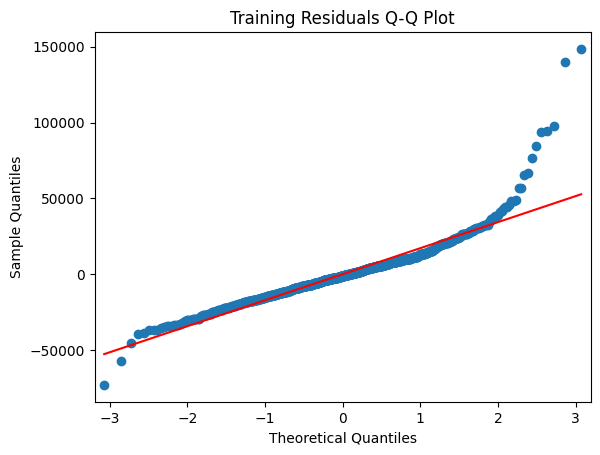

Anderson-Darling (Train) p-value: 0.0


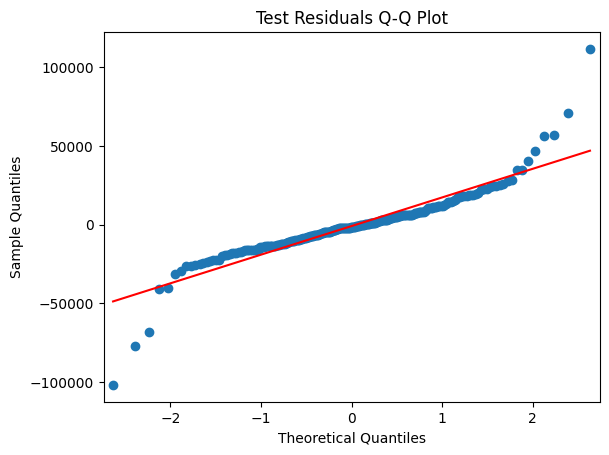

Anderson-Darling (Test) p-value: 4.492398152592996e-14


In [24]:
print("Jarque-Bera p-value: " + str(jarque_bera(model.resid)[1]))

predictions_test = model.predict(X_test_normalized)
residuals_test = y_test - predictions_test

sm.qqplot(model.resid, line='r')
plt.title("Training Residuals Q-Q Plot")
plt.show()
ad_test_train = diag.normal_ad(model.resid)[1]
print("Anderson-Darling (Train) p-value: " + str(ad_test_train))

sm.qqplot(residuals_test, line='r')
plt.title("Test Residuals Q-Q Plot")
plt.show()
ad_test_test = diag.normal_ad(residuals_test)[1]
print("Anderson-Darling (Test) p-value: " + str(ad_test_test))

The homoscedasticity assumption will be examined using White's test and a scatter plot.

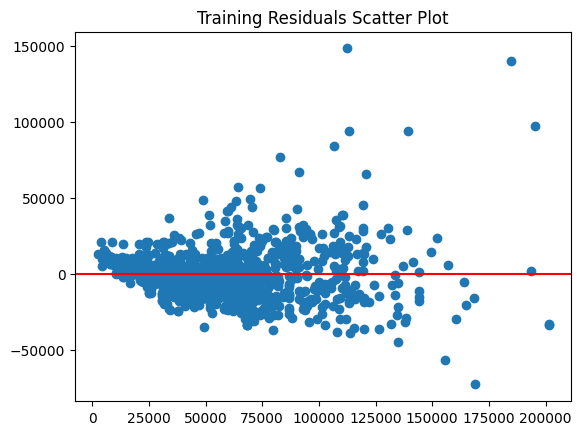

White's p-value: 1.2094702234966195e-15


In [16]:
plt.scatter(model.predict(X_train_normalized), model.resid)
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Training Residuals Scatter Plot")
plt.show()
white_test_train = diag.het_white(model.resid, X_train_normalized)[1]
print("White's p-value: " + str(white_test_train))

In order to examine model adequacy, the adjusted R-squared value for the test data will be caluclated. This will be compared with the value for the training data calculated above (these values shouldn't be too far apart). The F-statsitic, Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) from the OLS summary will also be considered.

In [20]:
r2 = r2_score(y_test, predictions_test)
n, p = len(y_test), len(model.params) - 1
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-squared (Test): " + str(adjusted_r2))
print("Adjusted R-squared (Train): " + str(model.rsquared_adj))
print('')
print("F-statistic p-value: " + str(model.f_pvalue))
print("AIC: " + str(model.aic))
print("BIC: " + str(model.bic))

Adjusted R-squared (Test): 0.5772074333911859
Adjusted R-squared (Train): 0.7591135580455863

F-statistic p-value: 1.3440048423843939e-248
AIC: 21090.993499863842
BIC: 21328.180279798988


All of the calculated p-values are below the critical value of 0.05. The points in the qq-plots don't match the lines and the scatter plot shows a cone shape. Lastly, the adjusted r-squared values are somewhat far apart, and they, along with the AIC and BIC, aren't ideal. All of these indicate that the model is inadequate and that the assumptions regarding normality of residuals and homoscedasticity aren't met. These issues will be addressed in the next notebook.

### Lastly, X and y are recombined into a single table and the data is saved.

In [21]:
Laptop_Data_Reduced = pd.concat([X, y], axis=1)
Laptop_Data_Reduced.to_csv('Laptop_Data_Reduced.csv', index=False)